In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/deliverylens_clean.csv')
print("Shape:", df.shape)
df.head()

Shape: (114092, 19)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,review_id,review_score,review_creation_date,is_bad_review,delivery_delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-02-10 10:56:00,2017-02-10 11:07:00,2017-04-10 19:55:00,2017-10-10 21:25:00,2017-10-18,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,a54f0611adc9ed256b57ede6b6eb5114,4.0,11-10-17 00:00,0.0,-8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00,2018-07-26 03:24:00,2018-07-26 14:31:00,2018-07-08 15:27:00,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,8d5266042046a06655c8db133d120ba5,4.0,08-08-18 00:00,0.0,-36.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00,2018-08-08 08:55:00,2018-08-08 13:50:00,2018-08-17 18:06:00,2018-04-09,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,e73b67b67587f7644d5bd1a52deb1b01,5.0,18-08-18 00:00,0.0,130.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:00,2017-11-18 19:45:00,2017-11-22 13:39:00,2017-02-12 00:28:00,2017-12-15,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,359d03e676b3c069f62cadba8dd3f6e8,5.0,03-12-17 00:00,0.0,-306.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:00,2018-02-13 22:20:00,2018-02-14 19:46:00,2018-02-16 18:17:00,2018-02-26,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,e50934924e227544ba8246aeb3770dd4,5.0,17-02-18 00:00,0.0,-10.0


1️⃣ Order Status distribution

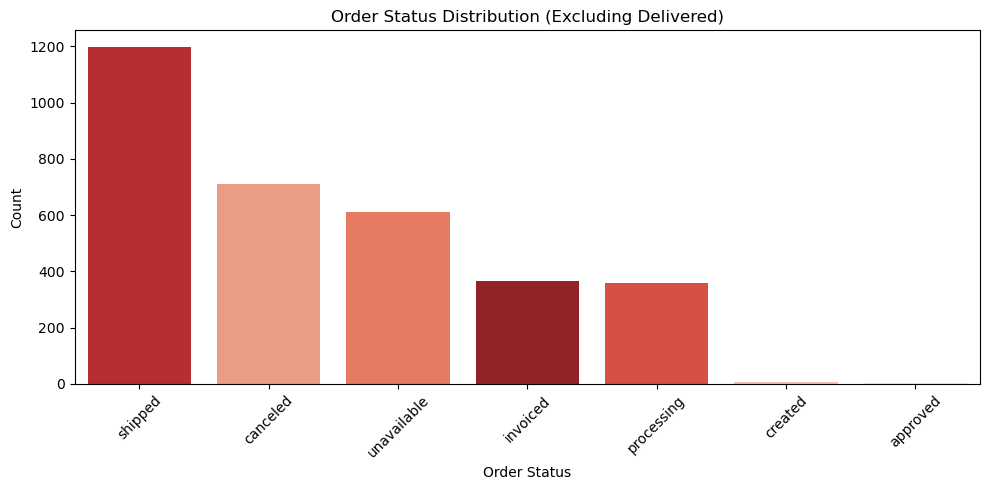

In [2]:
# Delivered hata ke baaki dekho
df_other = df[df['order_status'] != 'delivered']

plt.figure(figsize=(10, 5))
sns.countplot(data=df_other, x='order_status',
              order=df_other['order_status'].value_counts().index,
              hue='order_status',
              legend=False,
              palette='Reds_r')
plt.title('Order Status Distribution (Excluding Delivered)')
plt.xlabel('Order Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight**: 
97% orders delivered successfully, but 700 cancellations and 600 unavailable orders represent direct revenue loss.

2️⃣ Bad Review Rate

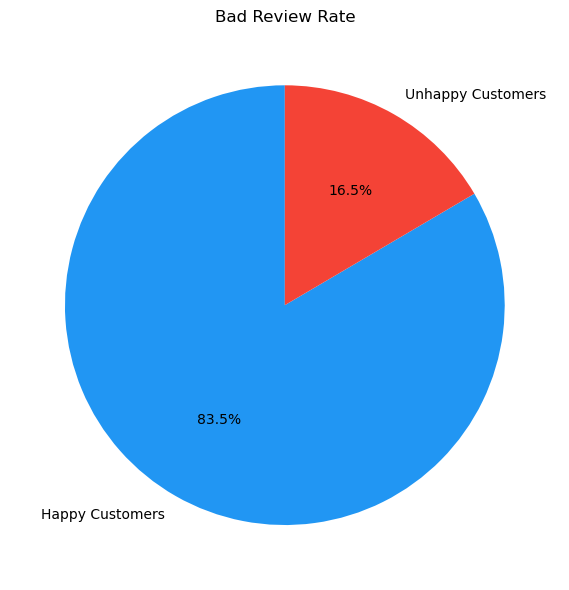

In [3]:
bad_review_rate = df['is_bad_review'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 6))
plt.pie(bad_review_rate, 
        labels=['Happy Customers', 'Unhappy Customers'],
        autopct='%1.1f%%',
        colors=['#2196F3', '#F44336'],
        startangle=90)
plt.title('Bad Review Rate')
plt.tight_layout()
plt.show()

**Insight**: 
1 in every 6 customers was unhappy — at scale, this is a significant satisfaction problem worth investigating.

3️⃣ Review Score Distribution:

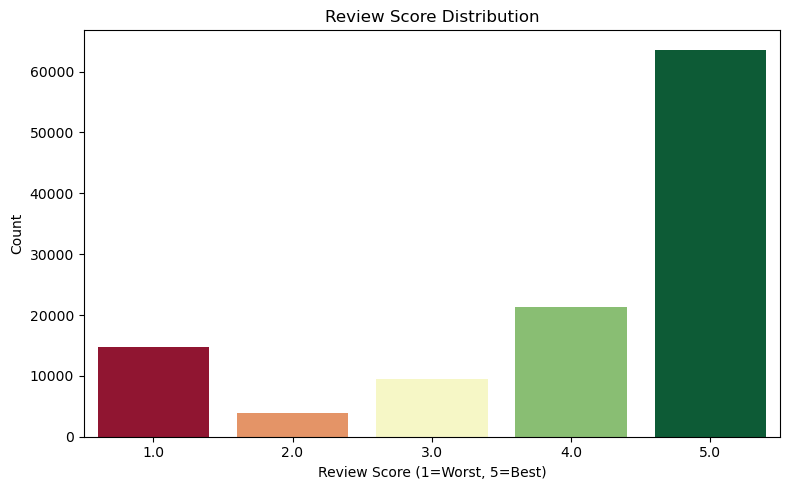

In [4]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='review_score',
              hue='review_score',
              legend=False,
              palette='RdYlGn')
plt.title('Review Score Distribution')
plt.xlabel('Review Score (1=Worst, 5=Best)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Insight**: Customer experience is highly polarized — most customers rated 5 stars, but 1-star is the third highest rating, indicating a significant dissatisfied segment.

4️⃣ Delivery Delay Distribution

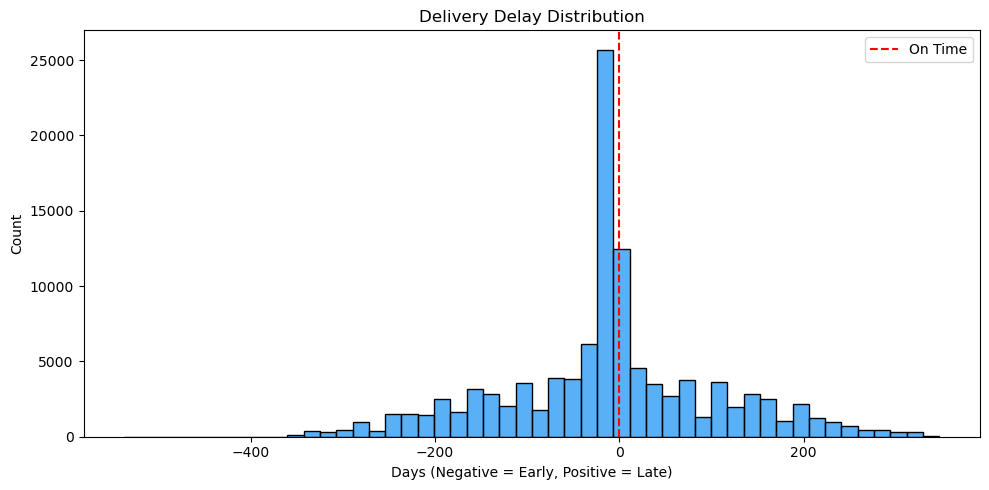

In [5]:

delay_df = df[df['delivery_delay_days'].notna()]

plt.figure(figsize=(10, 5))
sns.histplot(data=delay_df, x='delivery_delay_days', 
             bins=50, color='#2196F3')
plt.axvline(x=0, color='red', linestyle='--', label='On Time')
plt.title('Delivery Delay Distribution')
plt.xlabel('Days (Negative = Early, Positive = Late)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

**Insight**: Most orders were delivered early (negative side dominates), but a significant tail of 200+ days late exists — these extreme delays are likely the biggest drivers of bad reviews.

5️⃣ Late Delivery vs Bad Review

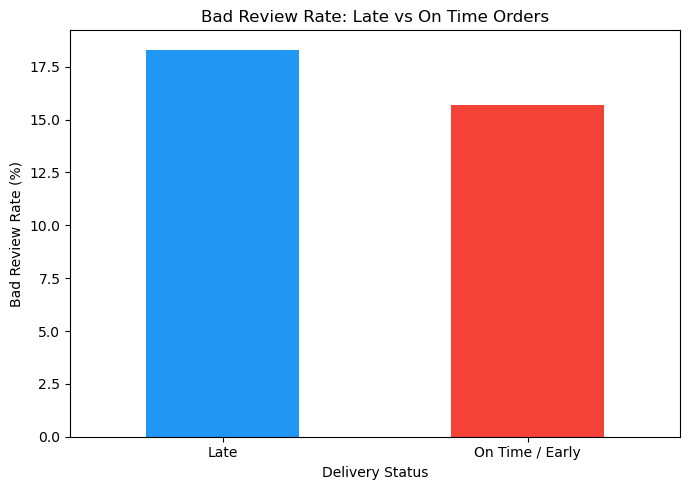

In [6]:

df['is_late'] = df['delivery_delay_days'].apply(
    lambda x: 'Late' if x > 0 else 'On Time / Early'
)

late_bad = df.groupby('is_late')['is_bad_review'].mean() * 100

plt.figure(figsize=(7, 5))
late_bad.plot(kind='bar', color=['#2196F3', '#F44336'])
plt.title('Bad Review Rate: Late vs On Time Orders')
plt.xlabel('Delivery Status')
plt.ylabel('Bad Review Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight** : Late orders have 18.5% bad review rate vs 15.9% for on-time orders — delivery delay does impact satisfaction, but the difference is smaller than expected, suggesting other factors also cause unhappiness.

6️⃣ Monthly Order Trend

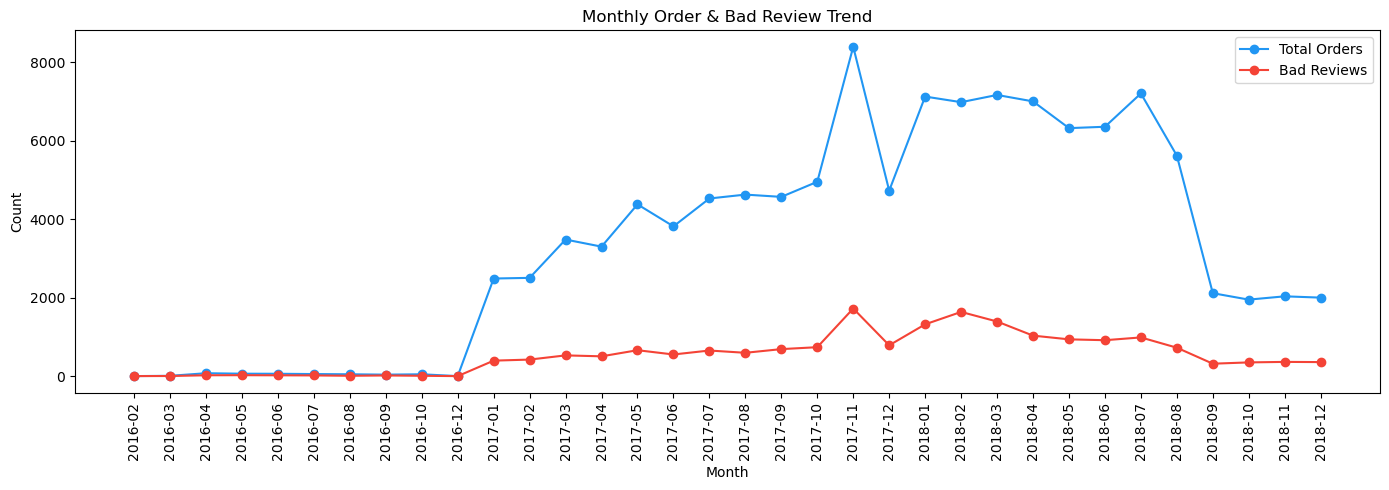

In [7]:
df['order_month'] = pd.to_datetime(df['order_purchase_timestamp']).dt.to_period('M')

monthly = df.groupby('order_month').agg(
    total_orders=('order_id', 'count'),
    bad_reviews=('is_bad_review', 'sum')
).reset_index()

monthly['order_month'] = monthly['order_month'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly['order_month'], monthly['total_orders'], 
         color='#2196F3', label='Total Orders', marker='o')
plt.plot(monthly['order_month'], monthly['bad_reviews'], 
         color='#F44336', label='Bad Reviews', marker='o')
plt.title('Monthly Order & Bad Review Trend')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

**Insight** : Orders grew rapidly from late 2016 to late 2017, peaking in November 2017 — likely a sale event. Bad reviews followed the same growth pattern, suggesting the platform struggled to maintain quality during rapid scaling.